In [1]:
%cd ../

/Users/Efecan/Desktop/Thesus/vision_transformer


In [4]:
import torch
from models.vision_transformer import VisionTransformer  


model = VisionTransformer(img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=256,
        depth=12,
        num_heads=8,
        hidden_size=1024,  
        dropout=0.1)  


weights_path = "model_weights/model_swapped/model_weights.pth"
model.load_state_dict(torch.load(weights_path, map_location=torch.device('mps'), weights_only=True))  # Use 'cuda' for GPU

model.eval()

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x TransformerEncoderBlock(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=256, out_features=1024, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=1024, out_features=256, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=10, bias=True)
)

In [5]:
print(model.pos_embed)  
print(model.blocks[0].attn.qkv.weight)  


for name, param in model.named_parameters():
    print(name, param.shape)

Parameter containing:
tensor([[[ 0.0195, -0.0095,  0.0251,  ...,  0.0045, -0.0094,  0.0069],
         [ 0.0124,  0.0189, -0.0404,  ..., -0.0144, -0.0386,  0.0255],
         [ 0.0286, -0.0209, -0.0287,  ..., -0.0448, -0.0460,  0.0581],
         ...,
         [-0.0080, -0.0034, -0.0077,  ..., -0.0241, -0.0036,  0.0064],
         [-0.0356,  0.0284, -0.0260,  ..., -0.0186, -0.0263,  0.0081],
         [ 0.0021, -0.0079, -0.0130,  ..., -0.0077, -0.0256,  0.0314]]],
       requires_grad=True)
Parameter containing:
tensor([[ 0.0657, -0.0191,  0.0800,  ...,  0.0564,  0.0327, -0.0310],
        [-0.0126,  0.0282,  0.0038,  ...,  0.0324,  0.0353,  0.1096],
        [ 0.0047,  0.0306, -0.0023,  ..., -0.0474,  0.0137, -0.0368],
        ...,
        [-0.0155,  0.0455,  0.0578,  ..., -0.0340,  0.0072,  0.0211],
        [ 0.0468, -0.0525,  0.0149,  ...,  0.0355,  0.0473, -0.0500],
        [ 0.0019,  0.0014, -0.0037,  ...,  0.0667,  0.0418, -0.0044]],
       requires_grad=True)
cls_token torch.Size([1, 1

In [6]:
layer_weights = [block.attn.qkv.weight for block in model.blocks]

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


def preprocess(w):
    return w.cpu().detach().numpy().reshape(-1)

weights = [preprocess(w) for w in layer_weights]
similarity_matrix = cosine_similarity(weights)

In [9]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import linear_sum_assignment


n_layers = 12
n_features = 256  # Example feature size
np.random.seed(42)  # For reproducibility
weights = [np.random.randn(n_features) for _ in range(n_layers)]

def align_permutation(w_source, w_target):

    # Reshape to 2D arrays
    w_source = w_source.reshape(1, -1)  # Shape: (1, n_features)
    w_target = w_target.reshape(1, -1)  # Shape: (1, n_features)

    # Compute cosine similarity matrix
    similarity_matrix = cosine_similarity(w_source, w_target)  # Shape: (1, 1)

    # Compute cost matrix (1 - similarity)
    cost_matrix = 1 - similarity_matrix  # Shape: (1, 1)

    # Solve the assignment problem (Hungarian algorithm)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    # Permute w_target accordingly
    aligned_w_target = w_target[col_ind].reshape(-1)  # Shape: (n_features,)

    return aligned_w_target

# Initialize the similarity matrix
similarity = np.zeros((n_layers, n_layers))

for i in range(n_layers):
    for j in range(n_layers):
        aligned_wj = align_permutation(weights[i], weights[j])  # Align j to i
        # Compute cosine similarity between aligned weights
        sim = cosine_similarity(weights[i].reshape(1, -1), aligned_wj.reshape(1, -1))
        similarity[i, j] = sim[0, 0]  # Extract scalar value

# Display the similarity matrix
print("Similarity Matrix:")
print(similarity)


Similarity Matrix:
[[ 1.00000000e+00 -1.27587135e-02  5.32162703e-02 -1.14436811e-01
   4.84069804e-02  9.54608539e-03  9.81806913e-02 -5.00111828e-03
  -1.15622042e-02 -2.25464667e-02 -1.42361265e-02 -1.27783972e-01]
 [-1.27587135e-02  1.00000000e+00  3.91185281e-02 -7.74388038e-02
   8.75823602e-02  9.41933105e-02 -6.56704390e-02 -4.32052715e-02
   1.53412864e-02  5.26061209e-02  1.21369449e-02  2.43634204e-02]
 [ 5.32162703e-02  3.91185281e-02  1.00000000e+00 -1.34266643e-01
   8.19416836e-02  2.37508951e-02  9.11388855e-02  2.55377001e-02
  -1.02819502e-01  4.46073386e-02 -4.98780154e-02  1.29051778e-01]
 [-1.14436811e-01 -7.74388038e-02 -1.34266643e-01  1.00000000e+00
   7.12104189e-02  3.04211091e-02 -3.60525075e-02 -7.75861848e-02
  -5.89400460e-03 -4.88584285e-02  5.81037382e-02  1.08137632e-01]
 [ 4.84069804e-02  8.75823602e-02  8.19416836e-02  7.12104189e-02
   1.00000000e+00  7.14906189e-02 -4.71008622e-02 -2.48957403e-02
  -5.51494072e-02 -3.49244972e-04 -1.11124353e-02 -3.

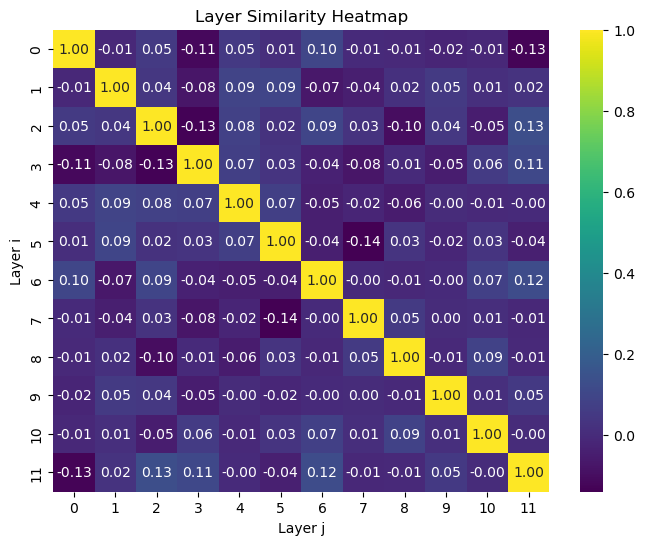

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'similarity' is your n_layers x n_layers similarity matrix
plt.figure(figsize=(8, 6))
sns.heatmap(similarity, annot=True, fmt=".2f", cmap='viridis')
plt.title('Layer Similarity Heatmap')
plt.xlabel('Layer j')
plt.ylabel('Layer i')
plt.show()


# Individual Layers

## Weight Distribution

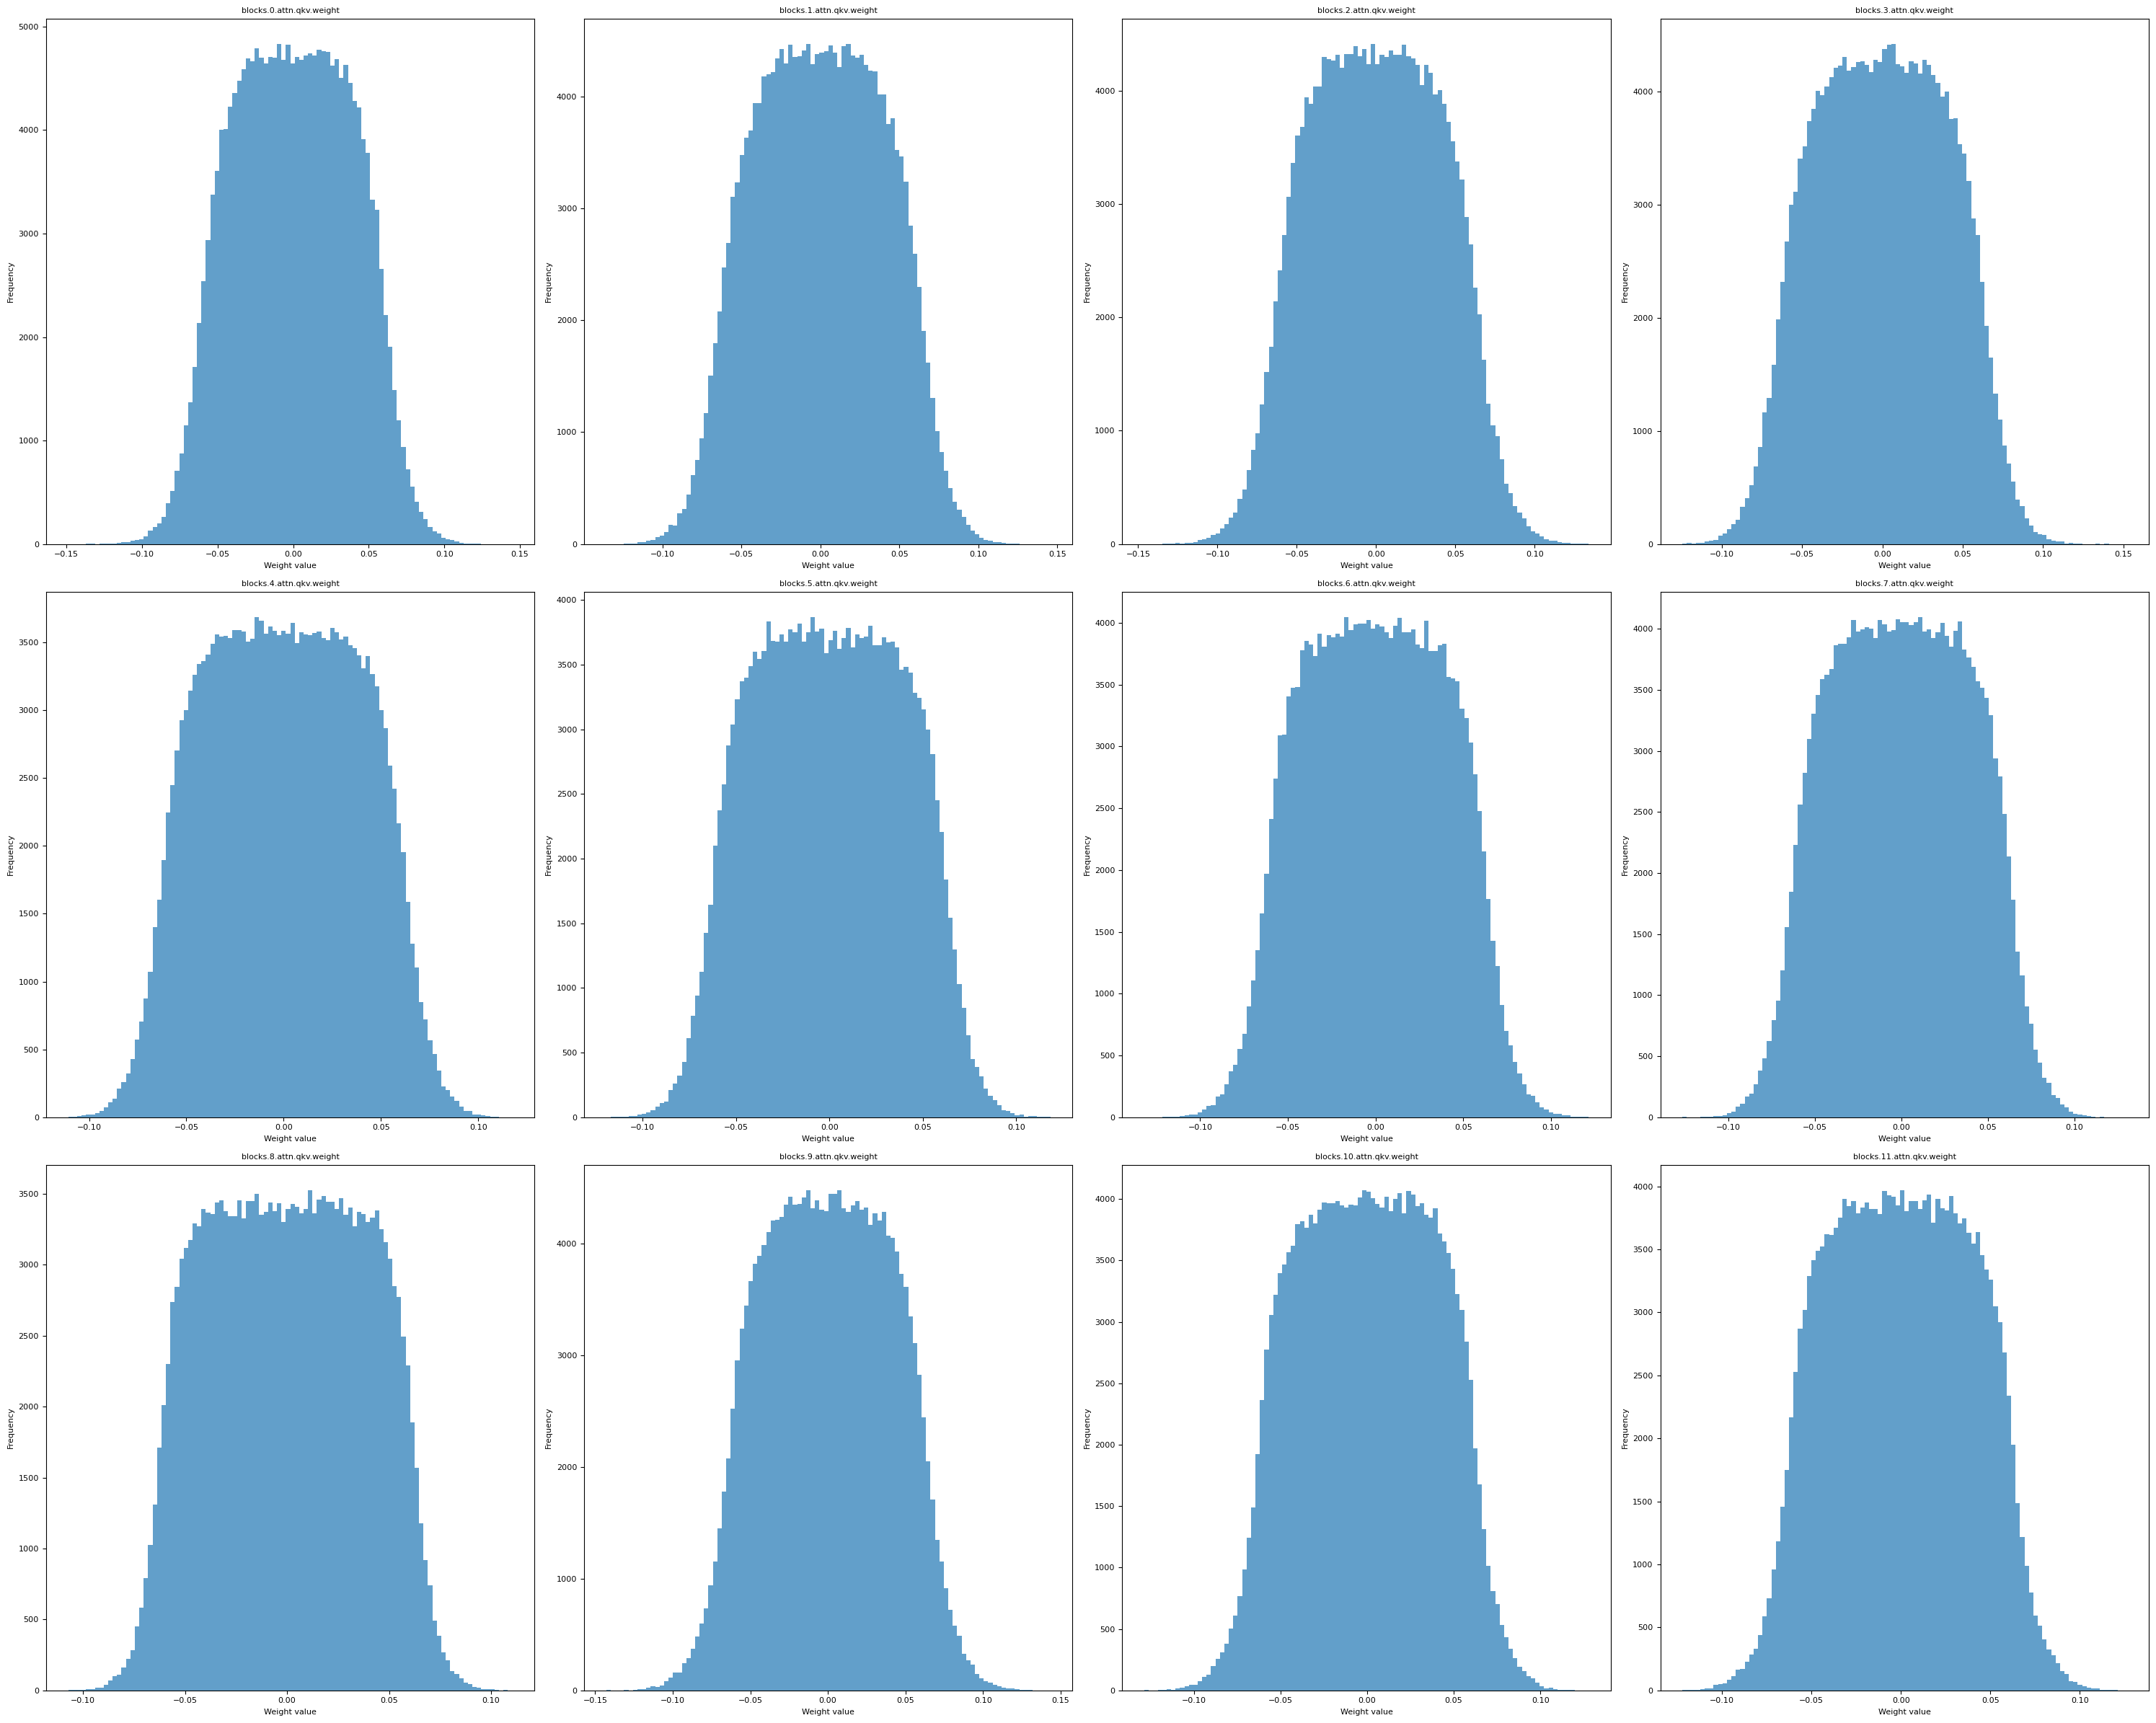

In [11]:
import matplotlib.pyplot as plt
import torch

def plot_weight_histogram(ax, model, layer_name):
    try:
        param = dict(model.named_parameters())[layer_name]
        weights = param.detach().cpu().numpy().flatten()
    except KeyError:
        print(f"Layer {layer_name} not found. Skipping plot.")
        ax.axis('off')
        return
    ax.hist(weights, bins=100, alpha=0.7)
    ax.set_title(f'{layer_name}', fontsize=8)
    ax.set_xlabel('Weight value', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=8)


encoder_layers = [name for name, param in model.named_parameters() 
                  if 'blocks' in name and 'attn.qkv.weight' in name]

if len(encoder_layers) != 12:
    print(f"Found {len(encoder_layers)} encoder layers. Adjust the name filtering if incorrect.")


fig, axes = plt.subplots(3, 4, figsize=(30, 24))
axes = axes.flat  


for ax, layer_name in zip(axes, encoder_layers[:12]): 
    plot_weight_histogram(ax, model, layer_name)

for ax in axes[len(encoder_layers):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Sparsity

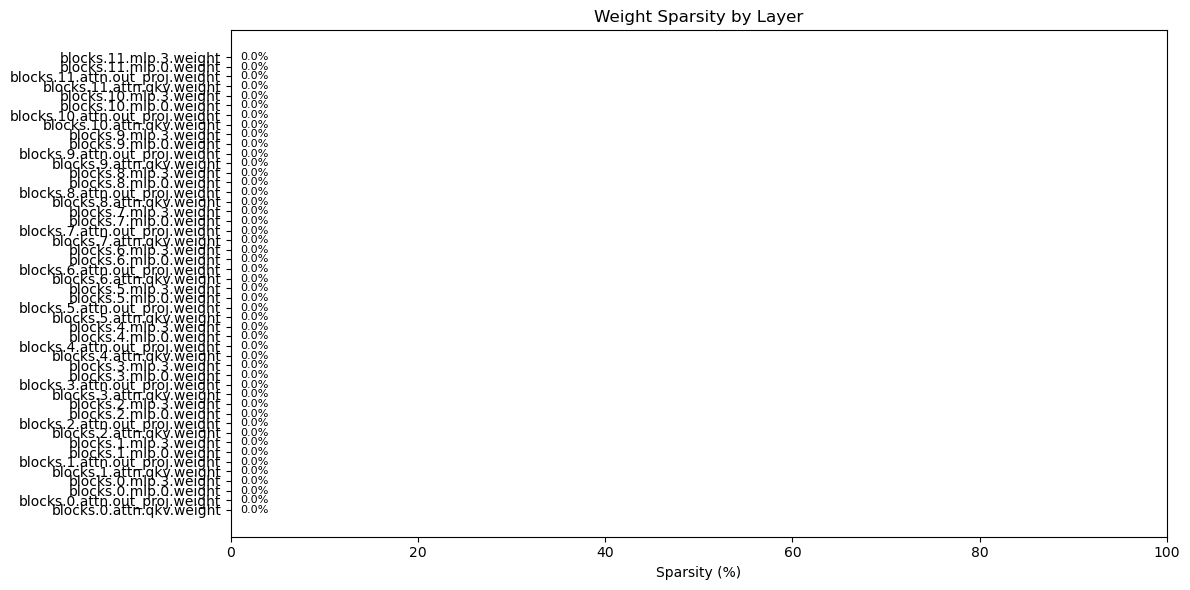

In [12]:
def compute_sparsity(model):
    sparsity_dict = {}
    
    for name, param in model.named_parameters():
        # Focus on attention and MLP weights in transformer blocks
        if 'blocks' in name and ('attn' in name or 'mlp' in name) and 'weight' in name:
            with torch.no_grad():
                num_zero = torch.sum(param == 0).item()
                total_elements = param.numel()
                sparsity = num_zero / total_elements if total_elements > 0 else 0
                
            sparsity_dict[name] = sparsity
    
    if not sparsity_dict:
        print("No weights found! Check your model architecture.")
        print("Debug - found parameters:", [n for n,_ in model.named_parameters()][:5])
        
    return sparsity_dict

def plot_sparsity(sparsity_dict):
    if not sparsity_dict:
        print("No data to plot!")
        return
        
    layers = list(sparsity_dict.keys())
    sparsities = [s * 100 for s in sparsity_dict.values()]
    
    plt.figure(figsize=(12, 6))
    bars = plt.barh(layers, sparsities, color='skyblue')
    plt.xlabel('Sparsity (%)')
    plt.title('Weight Sparsity by Layer')
    plt.xlim(0, 100)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}%', ha='left', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Usage
sparsity = compute_sparsity(model)
plot_sparsity(sparsity)

In [14]:
import numpy as np
import torch
import scipy
from scipy.stats import entropy
from sklearn.cross_decomposition import CCA
from scipy.spatial.distance import cdist
from scipy.linalg import svd

def centered_kernel_alignment(X, Y):
    """Centered Kernel Alignment (CKA) similarity between two representations"""
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    
    X = X.double()
    Y = Y.double()
    
    # Compute HSIC
    K = X @ X.T
    L = Y @ Y.T
    
    hsic = torch.trace(K @ L)
    norm_K = torch.trace(K @ K).sqrt()
    norm_L = torch.trace(L @ L).sqrt()
    
    return (hsic / (norm_K * norm_L)).item()

def cca_similarity(X, Y, n_components=50):
    """Canonical Correlation Analysis similarity"""
    cca = CCA(n_components=n_components, max_iter=1000)
    X_c, Y_c = cca.fit_transform(X.detach().cpu().numpy(),
                                Y.detach().cpu().numpy())
    
    # Compute mean correlation
    corrs = [np.corrcoef(X_c[:,i], Y_c[:,i])[0,1] 
            for i in range(n_components)]
    return np.mean(corrs)

def mutual_information(X, Y, bins=50):
    """Mutual Information between layer representations"""
    x = X.detach().cpu().numpy().flatten()
    y = Y.detach().cpu().numpy().flatten()
    
    # Joint histogram
    hist_xy = np.histogram2d(x, y, bins=bins)[0]
    hist_x = np.histogram(x, bins=bins)[0]
    hist_y = np.histogram(y, bins=bins)[0]
    
    # Convert to probabilities
    p_xy = hist_xy / np.sum(hist_xy) + 1e-10
    p_x = hist_x / np.sum(hist_x) + 1e-10
    p_y = hist_y / np.sum(hist_y) + 1e-10
    
    # Compute MI
    mi = np.sum(p_xy * np.log(p_xy / (p_x[:, None] * p_y[None, :])))
    return mi

def svd_angular_similarity(W1, W2, k=10):
    """SVD-based principal angle similarity"""
    U1, _, _ = svd(W1.detach().cpu().numpy(), full_matrices=False)
    U2, _, _ = svd(W2.detach().cpu().numpy(), full_matrices=False)
    
    # Take top-k components
    cos_sims = np.diag(U1[:, :k].T @ U2[:, :k])
    return np.mean(np.arccos(np.clip(cos_sims, -1, 1)))

def emd_distance(W1, W2):
    """Earth Mover's Distance between weight distributions"""
    x = W1.detach().cpu().numpy().flatten()
    y = W2.detach().cpu().numpy().flatten()
    
    # Create normalized histograms
    hist_x = np.histogram(x, bins=100, density=True)[0]
    hist_y = np.histogram(y, bins=100, density=True)[0]
    
    # Compute EMD
    distance = scipy.stats.wasserstein_distance(hist_x, hist_y)
    return distance

def analyze_layer_relationships(model, layer_names):
    """Compute all metrics for pairwise layer comparisons"""
    metrics = {
        'cka': [],
        'cca': [],
        'mi': [],
        'svd_angle': [],
        'emd': []
    }
    
    # Get layer parameters
    params = {name: param for name, param in model.named_parameters() 
             if name in layer_names}
    
    # Compare all pairs
    layers = list(params.keys())
    for i, name1 in enumerate(layers):
        row = {'cka': [], 'cca': [],'mi': [], 'svd_angle': [], 'emd': []}
        W1 = params[name1]
        print(i)
        for j, name2 in enumerate(layers):
            W2 = params[name2]
            
            # Reshape parameters to 2D matrices
            X = W1.view(W1.size(0), -1).T  # [neurons, inputs]
            Y = W2.view(W2.size(0), -1).T
            
            # Compute metrics
            row['cka'].append(centered_kernel_alignment(X, Y))
            row['cca'].append(cca_similarity(X, Y))
            row['mi'].append(mutual_information(X, Y))
            row['svd_angle'].append(svd_angular_similarity(X, Y))
            row['emd'].append(emd_distance(X, Y))
            
        for k in metrics:
            metrics[k].append(row[k])
            
    return metrics, layers



In [15]:
layer_names = [f'blocks.{i}.attn.qkv.weight' for i in range(12)]


metrics, layers = analyze_layer_relationships(model, layer_names)

0
1
2
3
4
5
6
7
8
9
10
11


In [16]:
def plot_metric_matrix(metric_matrix, layer_names, title):
    """Visualize similarity/distance matrix"""
    plt.figure(figsize=(12, 10))
    plt.imshow(metric_matrix, cmap='viridis')
    plt.colorbar()
    plt.xticks(np.arange(len(layer_names)), layer_names, rotation=90)
    plt.yticks(np.arange(len(layer_names)), layer_names)
    plt.title(title)
    plt.tight_layout()
    plt.show()

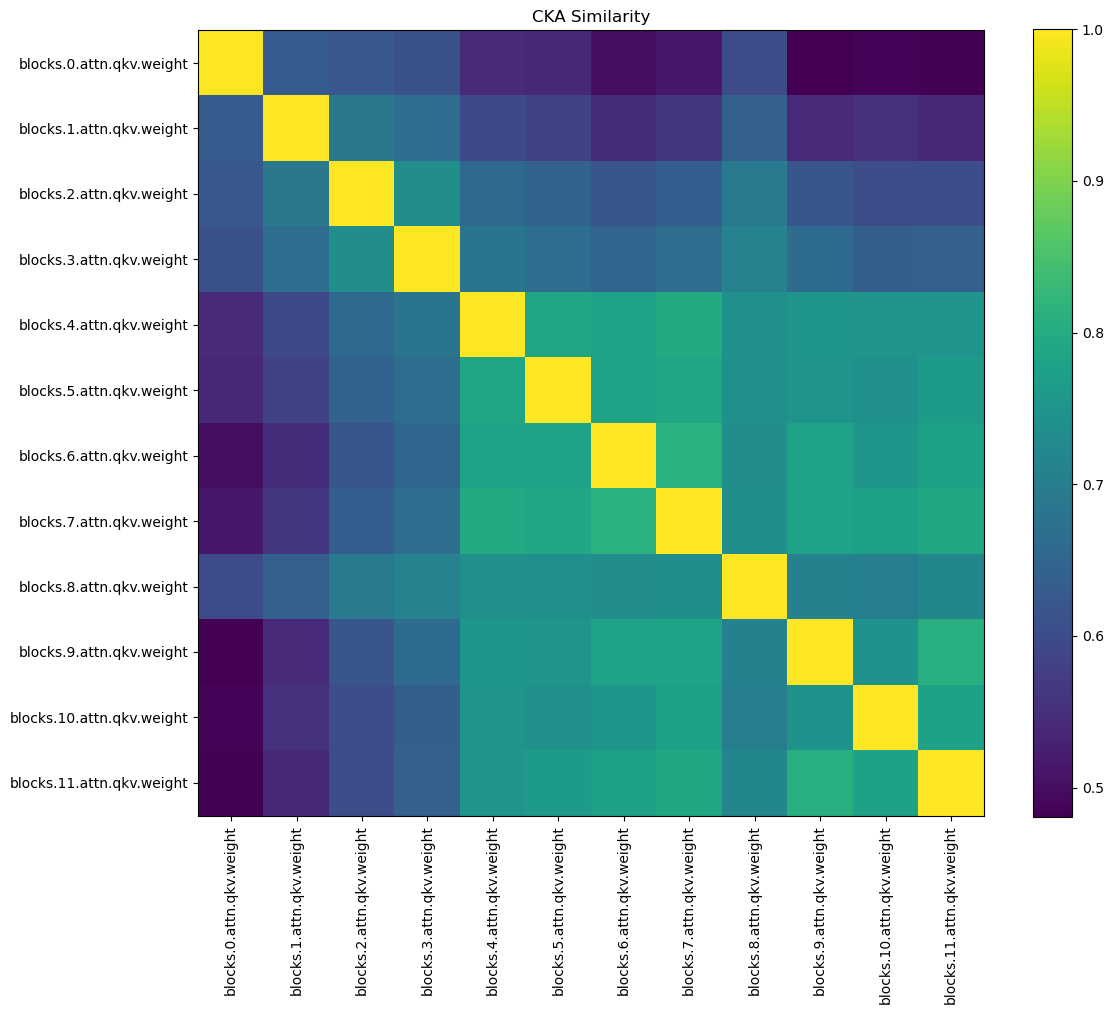

In [17]:
plot_metric_matrix(np.array(metrics['cka']), layers, 'CKA Similarity')

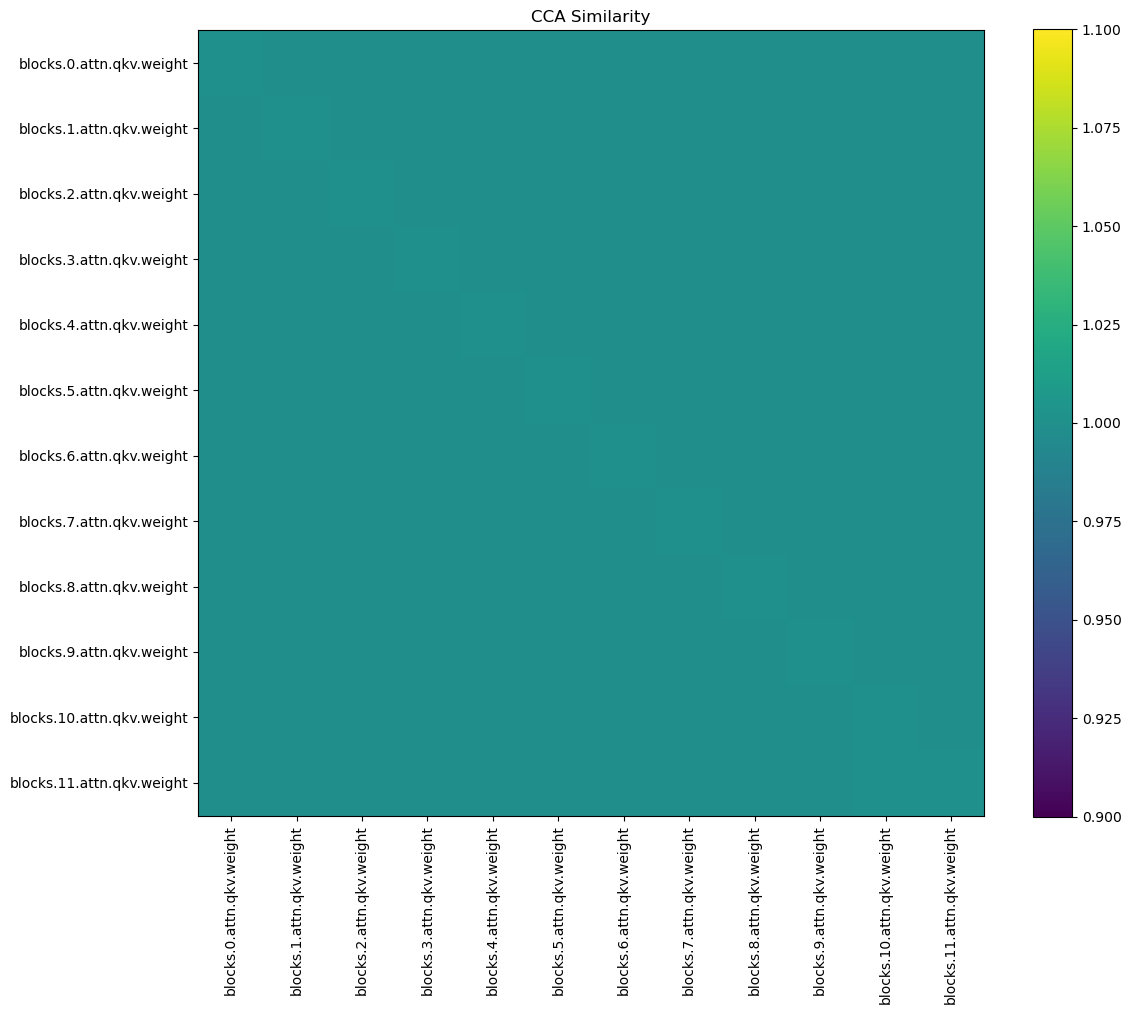

In [18]:
plot_metric_matrix(np.array(metrics['cca']), layers, 'CCA Similarity')

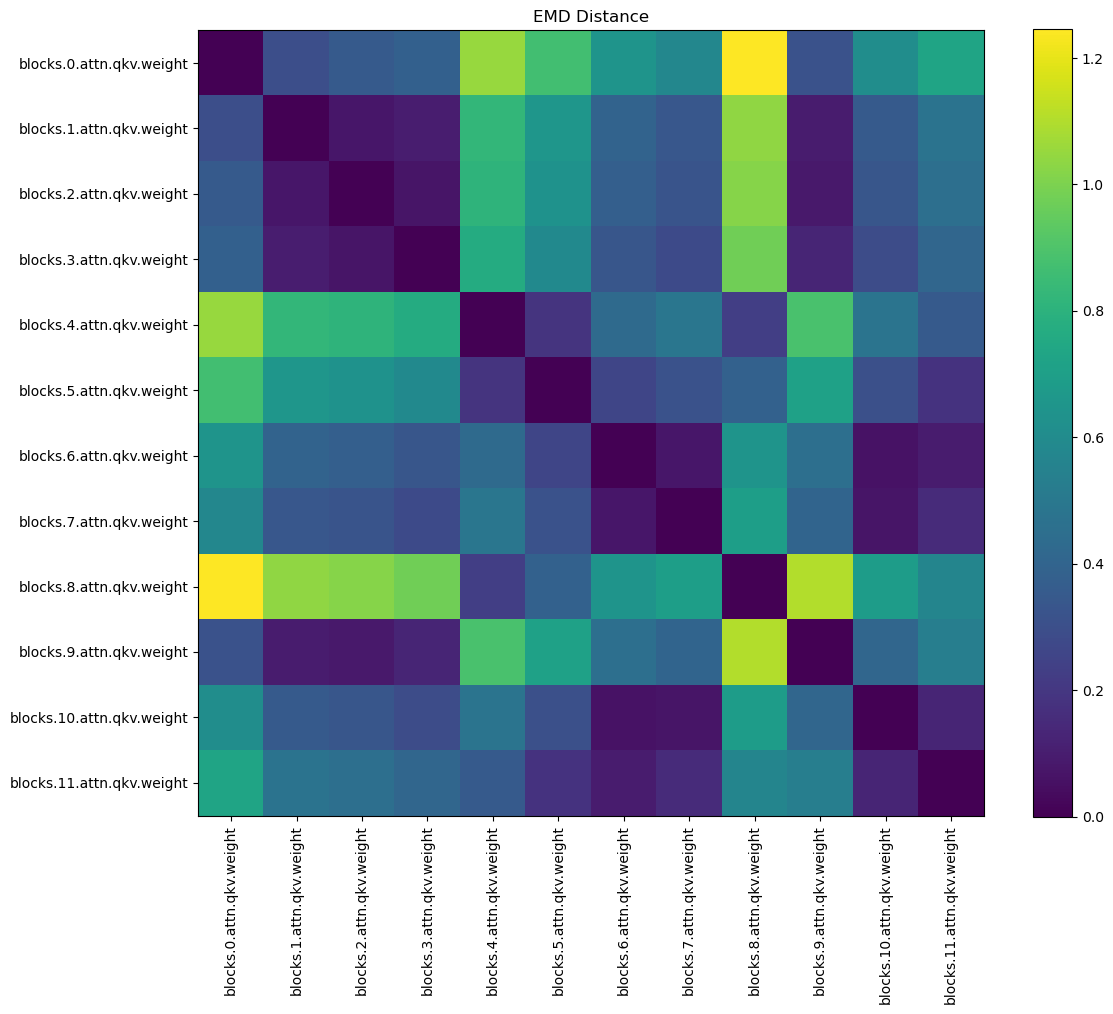

In [19]:
plot_metric_matrix(np.array(metrics['emd']), layers, 'EMD Distance')

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm  # For better color scaling

def visualize_single_model_metrics(metrics, layer_names, metric_keys=['mi', 'svd_angle']):
    """Visualize MI and SVD similarity matrices from pre-computed metrics"""
    fig, axs = plt.subplots(1, 2, figsize=(20, 8))
    
    # Shorten layer names for readability (e.g., "blocks.0.attn.qkv.weight" -> "L0")
    short_names = [f'L{i}' for i in range(len(layer_names))]
    
    for idx, metric_key in enumerate(metric_keys):
        matrix = np.array(metrics[metric_key])
        
        # Create heatmap
        im = axs[idx].imshow(matrix, cmap='viridis' if metric_key == 'mi' else 'plasma')
        
        # Configure plot
        axs[idx].set_title(f'{metric_key.upper()} Between Layers', fontsize=14)
        axs[idx].set_xticks(np.arange(len(short_names)))
        axs[idx].set_yticks(np.arange(len(short_names)))
        axs[idx].set_xticklabels(short_names, rotation=45, ha='right', fontsize=10)
        axs[idx].set_yticklabels(short_names, fontsize=10)
        
        # Add colorbar
        cbar = fig.colorbar(im, ax=axs[idx], shrink=0.8)
        cbar.set_label('MI (bits)' if metric_key == 'mi' else 'Angle (radians)', fontsize=12)
        
      

    plt.tight_layout()
    plt.show()

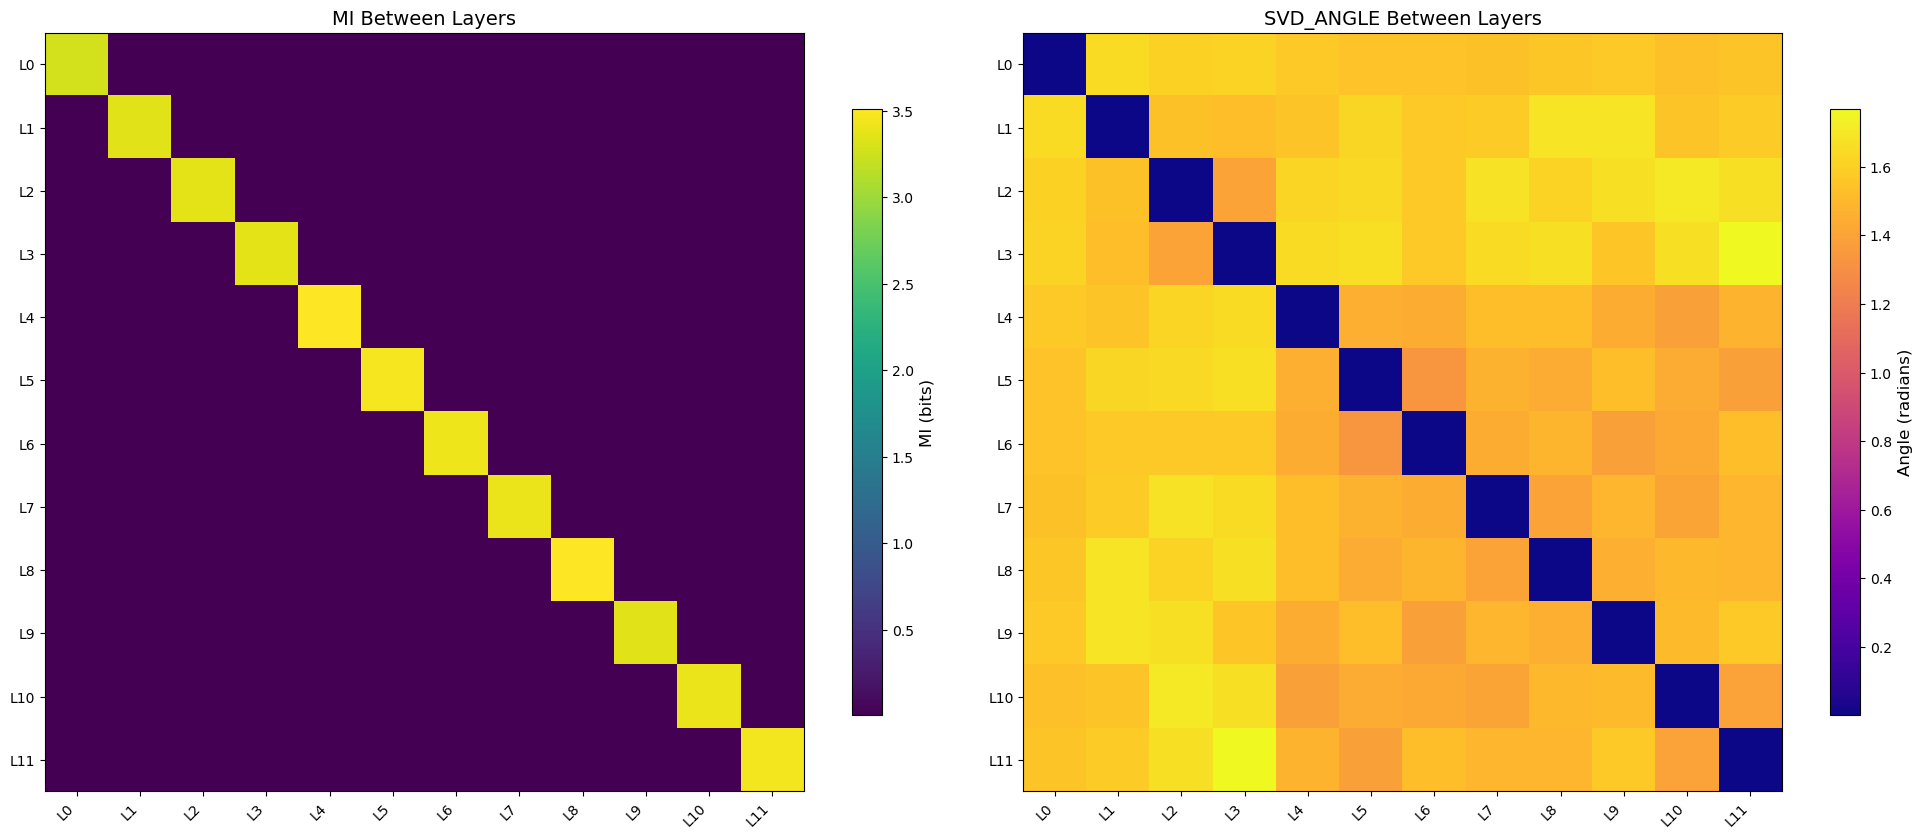

In [21]:
visualize_single_model_metrics(metrics, layers)

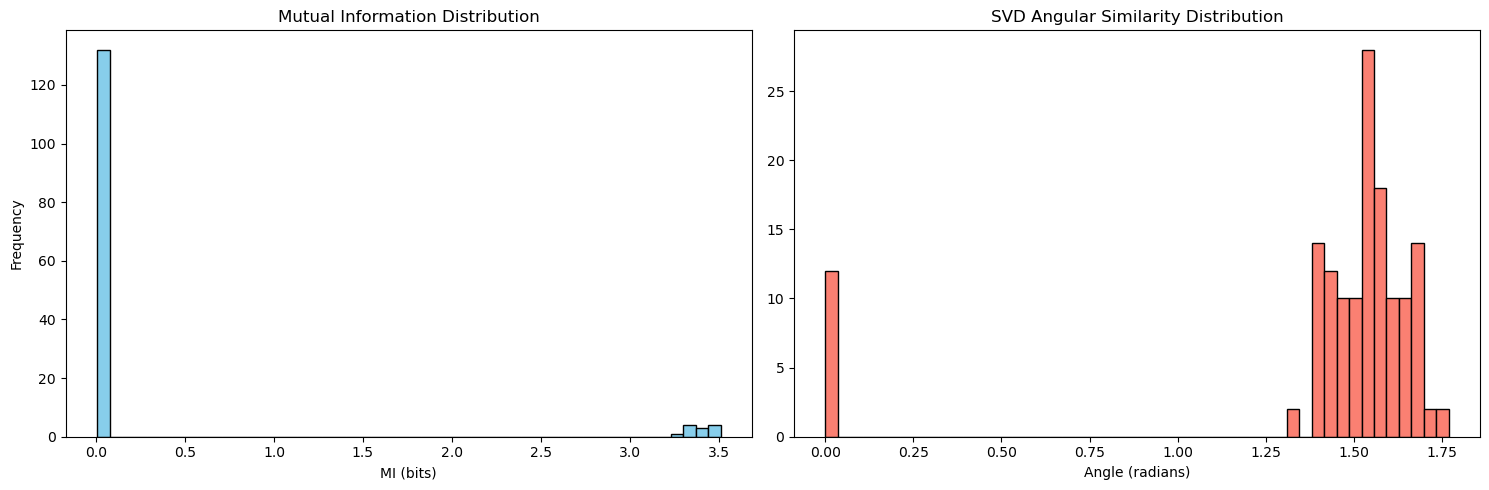

In [22]:
def plot_metric_distributions(metrics):
    """Plot histogram distributions of MI and SVD angles"""
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    
    # MI Distribution
    mi_vals = np.array(metrics['mi']).flatten()
    axs[0].hist(mi_vals, bins=50, color='skyblue', edgecolor='black')
    axs[0].set_title('Mutual Information Distribution')
    axs[0].set_xlabel('MI (bits)')
    axs[0].set_ylabel('Frequency')
    
    # SVD Angle Distribution
    svd_vals = np.array(metrics['svd_angle']).flatten()
    axs[1].hist(svd_vals, bins=50, color='salmon', edgecolor='black')
    axs[1].set_title('SVD Angular Similarity Distribution')
    axs[1].set_xlabel('Angle (radians)')
    
    plt.tight_layout()
    plt.show()

# Usage
plot_metric_distributions(metrics)

# Embedding Analysis

In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

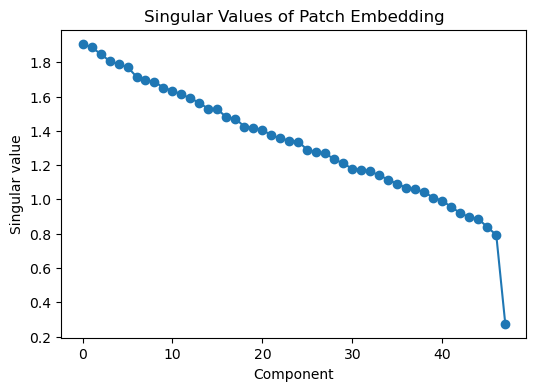

In [23]:
patch_embed_weight = model.patch_embed.proj.weight.data.clone()  # shape: [256, 3, 4, 4]
patch_embed_flat = patch_embed_weight.view(256, -1).cpu().numpy()  # [256, 3*4*4]

U, S, Vt = np.linalg.svd(patch_embed_flat, full_matrices=False)
plt.figure(figsize=(6,4))
plt.plot(S, 'o-')
plt.title("Singular Values of Patch Embedding")
plt.xlabel("Component")
plt.ylabel("Singular value")
plt.show()


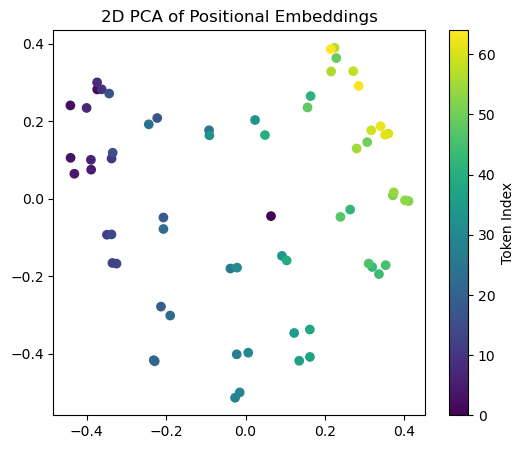

CLS Token norm =  0.15912807


In [26]:
pos_embed = model.pos_embed.data.clone().squeeze(0).cpu().numpy()  # shape: [65, 256]
pca = PCA(n_components=2)
pos_embed_2d = pca.fit_transform(pos_embed)  # shape: [65, 2]

plt.figure(figsize=(6,5))
plt.scatter(pos_embed_2d[:,0], pos_embed_2d[:,1], c=range(pos_embed_2d.shape[0]))
plt.title("2D PCA of Positional Embeddings")
plt.colorbar(label="Token Index")
plt.show()


cls_token = model.cls_token.data.clone().cpu().numpy()  
print("CLS Token norm = ", np.linalg.norm(cls_token))

In [30]:
for i in range(12):
    qkv_weight = model.blocks[i].attn.qkv.weight.data.clone().cpu().numpy()  
    

    q_weight = qkv_weight[0:256,:]
    k_weight = qkv_weight[256:512,:]
    v_weight = qkv_weight[512:768,:]
    
    # Example: analyze the singular values of Q
    _, S_q, _ = np.linalg.svd(q_weight, full_matrices=False)
    print(f"Block {i} - Q matrix top singular values:", S_q[:5])
    


Block 0 - Q matrix top singular values: [2.198833  1.7756004 1.7046164 1.6985877 1.5083793]
Block 1 - Q matrix top singular values: [2.907291  2.0470853 1.6587824 1.5280344 1.3962554]
Block 2 - Q matrix top singular values: [2.3825796 1.72704   1.6323956 1.5415329 1.4770029]
Block 3 - Q matrix top singular values: [2.7200177 1.6713685 1.4970369 1.4702743 1.3805763]
Block 4 - Q matrix top singular values: [3.2577488 1.4132807 1.2239991 1.1808366 1.1655154]
Block 5 - Q matrix top singular values: [3.3965752 1.5517759 1.3492861 1.2137151 1.1946539]
Block 6 - Q matrix top singular values: [4.0260735 1.6342251 1.4142686 1.3557817 1.2046312]
Block 7 - Q matrix top singular values: [3.7040873 1.6647111 1.468102  1.3982081 1.2126365]
Block 8 - Q matrix top singular values: [2.6376488 1.4800823 1.1598253 1.1467986 1.1346297]
Block 9 - Q matrix top singular values: [4.5831127 1.8339435 1.6600173 1.5663943 1.3853688]
Block 10 - Q matrix top singular values: [4.5715623 1.3214058 1.2045624 1.190933

In [31]:
for i in range(12):
    ff1_weight = model.blocks[i].mlp[0].weight.data.clone().cpu().numpy()  # [1024, 256]
    ff2_weight = model.blocks[i].mlp[3].weight.data.clone().cpu().numpy()  # [256, 1024]
    
  
    U_ff1, S_ff1, Vt_ff1 = np.linalg.svd(ff1_weight, full_matrices=False)
    rank_approx_ff1 = np.sum(S_ff1 > 1e-5)
    print(f"Block {i} - MLP layer1 rank ~ {rank_approx_ff1}")
    
 
    U_ff2, S_ff2, Vt_ff2 = np.linalg.svd(ff2_weight, full_matrices=False)
    rank_approx_ff2 = np.sum(S_ff2 > 1e-5)
    print(f"Block {i} - MLP layer2 rank ~ {rank_approx_ff2}")

Block 0 - MLP layer1 rank ~ 256
Block 0 - MLP layer2 rank ~ 256
Block 1 - MLP layer1 rank ~ 256
Block 1 - MLP layer2 rank ~ 256
Block 2 - MLP layer1 rank ~ 256
Block 2 - MLP layer2 rank ~ 256
Block 3 - MLP layer1 rank ~ 256
Block 3 - MLP layer2 rank ~ 256
Block 4 - MLP layer1 rank ~ 256
Block 4 - MLP layer2 rank ~ 256
Block 5 - MLP layer1 rank ~ 256
Block 5 - MLP layer2 rank ~ 256
Block 6 - MLP layer1 rank ~ 256
Block 6 - MLP layer2 rank ~ 256
Block 7 - MLP layer1 rank ~ 256
Block 7 - MLP layer2 rank ~ 256
Block 8 - MLP layer1 rank ~ 256
Block 8 - MLP layer2 rank ~ 256
Block 9 - MLP layer1 rank ~ 256
Block 9 - MLP layer2 rank ~ 256
Block 10 - MLP layer1 rank ~ 256
Block 10 - MLP layer2 rank ~ 256
Block 11 - MLP layer1 rank ~ 256
Block 11 - MLP layer2 rank ~ 256


In [32]:
def principal_subspace_angle(W1, W2, top_k=10):
    """
    Compute a simple angle (in radians) between the top-k principal subspaces
    (via SVD) of W1 and W2.
    """
    # SVD for each
    U1, _, _ = np.linalg.svd(W1, full_matrices=False)
    U2, _, _ = np.linalg.svd(W2, full_matrices=False)
    # Take top-k singular vectors
    U1_top = U1[:, :top_k]
    U2_top = U2[:, :top_k]
    
    # Orth projection U1_top * U1_top^T etc.
    # Alternatively we can compute angles via the canonical angles method.
    # For a simple measure, let's do trace of (U1_top^T U2_top U2_top^T U1_top).
    # The dimension of that product is top_k x top_k, and the trace is from 0..top_k.
    
    M = np.dot(U1_top.T, U2_top)
    # The subspace overlap can be measured via the sum of squared singular values of M
    # If they are identical subspaces, that sum=top_k. If they are orthonormal, sum=0.
    _, S_sub, _ = np.linalg.svd(M, full_matrices=False)
    overlap = np.sum(S_sub**2)
    
    # Convert "overlap" to an angle. Higher overlap => smaller angle.
    # For a single vector, angle = arccos( dot(...) ). For subspaces we can do e.g.
    # angle = arccos( sqrt(overlap / top_k) ).
    return np.arccos( np.sqrt( overlap / top_k ) )

# Example: compare QKV of layer 0 vs. layer 11
W0 = model.blocks[0].attn.qkv.weight.data.clone().cpu().numpy()
W11 = model.blocks[11].attn.qkv.weight.data.clone().cpu().numpy()

angle_0_11 = principal_subspace_angle(W0, W11, top_k=10)
print(f"Angle between top-10 principal subspaces of QKV@layer0 and layer11: {angle_0_11:.3f} radians")

Angle between top-10 principal subspaces of QKV@layer0 and layer11: 1.471 radians
